# Computer Vision using OpenCV


### Import Libraries

In [2]:
import cv2 
import numpy as np 
from matplotlib import pyplot as plt

### Image Read and Display

Current working directory: /home/jetson/Documents


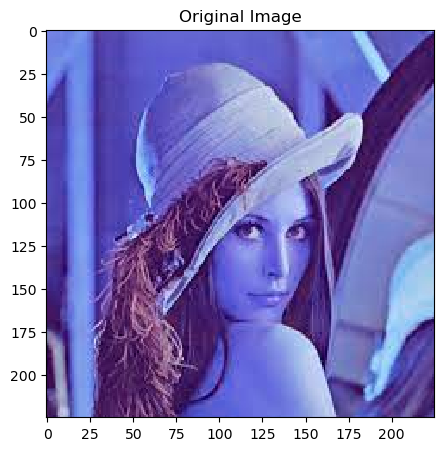

In [4]:
import os
print(f"Current working directory: {os.getcwd()}")

def display(image, caption = ' '):
    plt.figure(figsize = (5, 10))
    plt.title(caption) 
    plt.imshow(image)
    plt.show()

# Use absolute path
image_path = '/home/jetson/Documents/lena.jpg'
image = cv2.imread(image_path)
if image is None:
    print(f"Error: Could not load image '{image_path}'. Please check if the file exists.")
else:
    display(image, 'Original Image')

### Color Conversion 
- BGR to RGB 
- BGR to GRAY 
- BGR to HSV 
- BGR to YCrCb

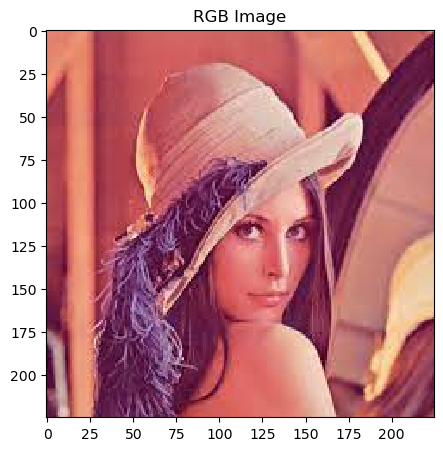

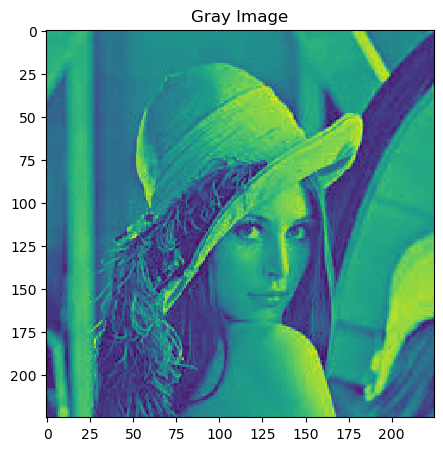

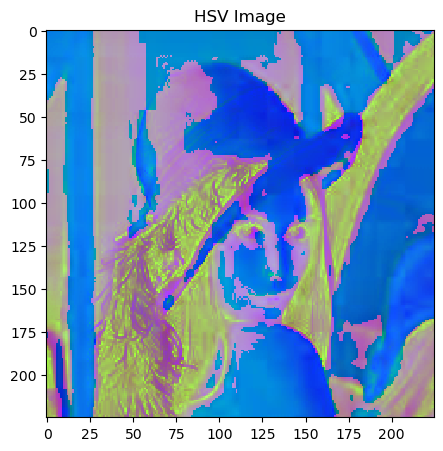

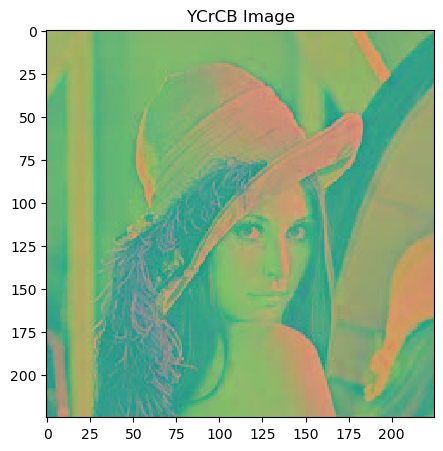

In [5]:
rgb = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(image,cv2.COLOR_BGR2HSV)
YCrCb = cv2.cvtColor(image,cv2.COLOR_BGR2YCrCb) 

display(rgb, 'RGB Image')
display(gray, 'Gray Image')
display(hsv, 'HSV Image')
display(YCrCb, 'YCrCB Image')

### Basic Filteration 

- Adding Noise
- Image Smoothing 
- Median Filter 

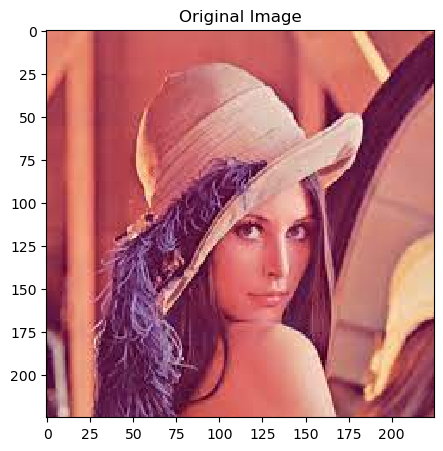

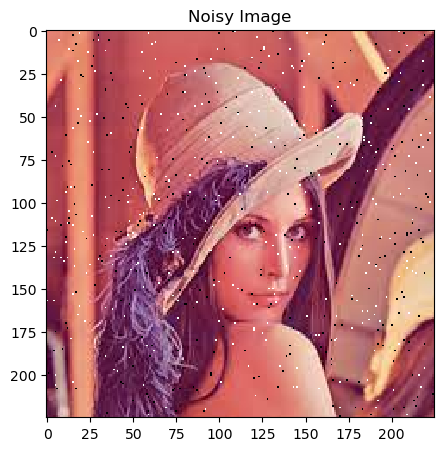

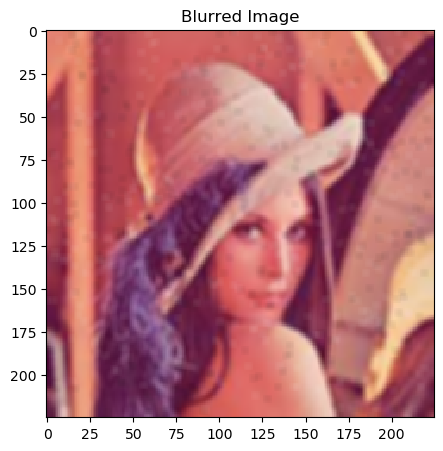

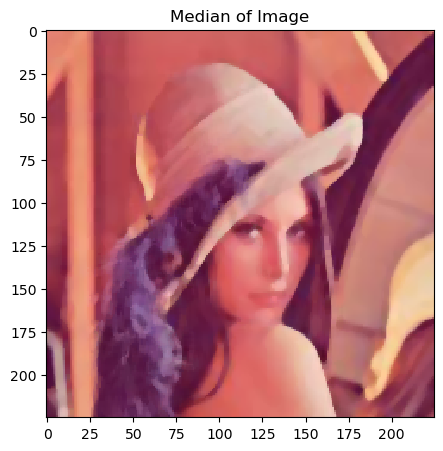

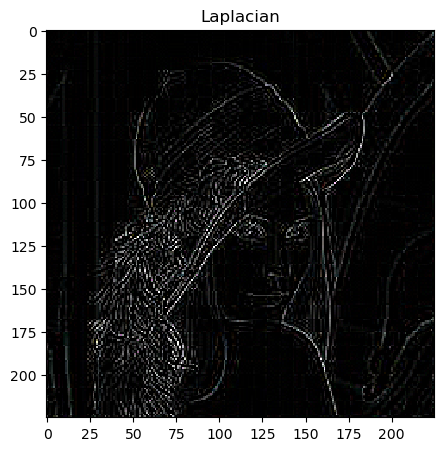

In [6]:
import random

def Blur(image = None, k = 5, s = 1):
    kernel = (5,5)
    sigma = 2
    blur = cv2.GaussianBlur(image,kernel,sigma)
    return blur

def add_noise(noisy_image = None):

    row,col,_ = noisy_image.shape
    number_of_pixels = random.randint(300, 1000)
    for i in range(number_of_pixels):
        y_coord=random.randint(0, row - 1)
        x_coord=random.randint(0, col - 1)          
        noisy_image[y_coord][x_coord][0] = 255
        noisy_image[y_coord][x_coord][1] = 255
        noisy_image[y_coord][x_coord][2] = 255

    for i in range(number_of_pixels):
        y_coord=random.randint(0, row - 1)
        x_coord=random.randint(0, col - 1)
        noisy_image[y_coord][x_coord][0] = 0
        noisy_image[y_coord][x_coord][1] = 0
        noisy_image[y_coord][x_coord][2] = 0
        
    return noisy_image


if __name__ == '__main__':
        
    noisy_image = add_noise(rgb.copy())
    image_blur = Blur(noisy_image.copy(), 5, 2) 
    median = cv2.medianBlur(noisy_image.copy(),5) 
    img = cv2.Laplacian(image.copy(),cv2.CV_8UC3)
    

    #Display all results
    display(rgb, 'Original Image')
    display(noisy_image, 'Noisy Image')
    display(image_blur, 'Blurred Image')
    display(median, 'Median of Image')
    display(img, 'Laplacian')

### Affine Transofrmation 

- Scaling 
- Translation
- Rotation 

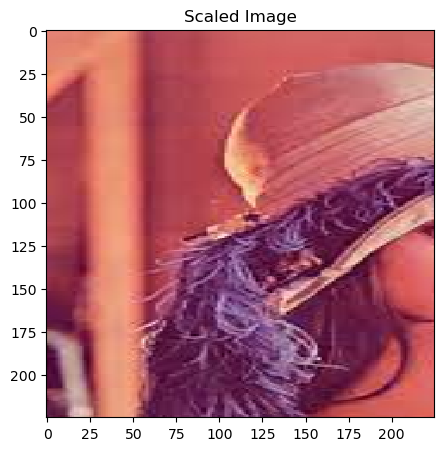

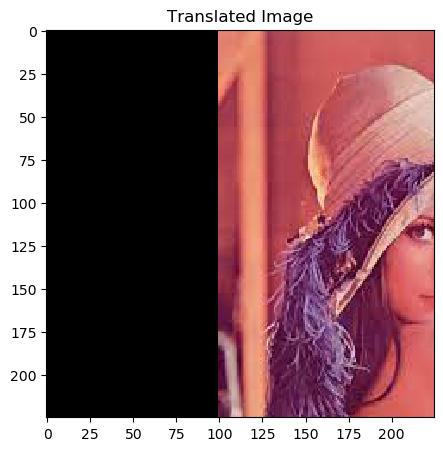

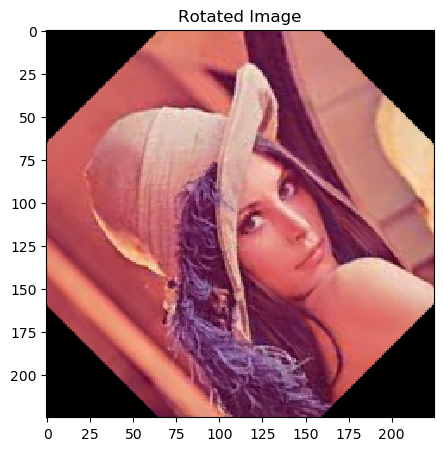

In [7]:
def Translation(image,x = 1,y = 1):
    h,w,_ = image.shape
    mat = np.float32([[1,0,x],[0,1,y]])
    trans = cv2.warpAffine(image,mat,(h,w))
    
    return trans

def Scaling(image,x = 1,y = 1):
    h,w,_ = image.shape
    mat = np.float32([[x,0,0],[0,y,0]])
    scale = cv2.warpAffine(image,mat,(h,w))
    
    return scale 

def Rotation(image,theta = 0):
    
    h,w,_ = image.shape
    center = (w/2, h/2)
    rotate_matrix = cv2.getRotationMatrix2D(center, angle = theta, scale=1)
    rotated_image = cv2.warpAffine(image, rotate_matrix, (w, h))
    
    return rotated_image



if __name__ == '__main__':
    
    img = rgb.copy()
    scaling = Scaling(img,2)
    
    translation = Translation(img,100)
    
    rotation = Rotation(img,45)
    
    display(scaling, 'Scaled Image')
    display(translation, 'Translated Image')
    display(rotation, 'Rotated Image')

### Edge Detection 

- Laplacian 
- Sobel
- Canny 

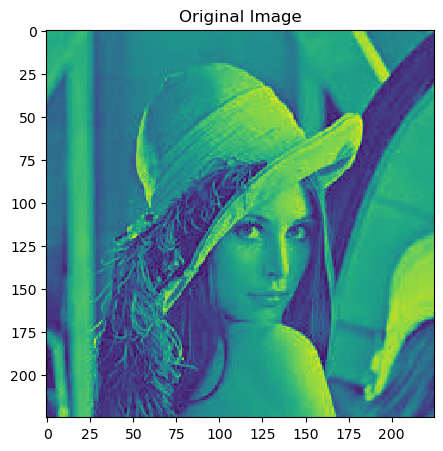

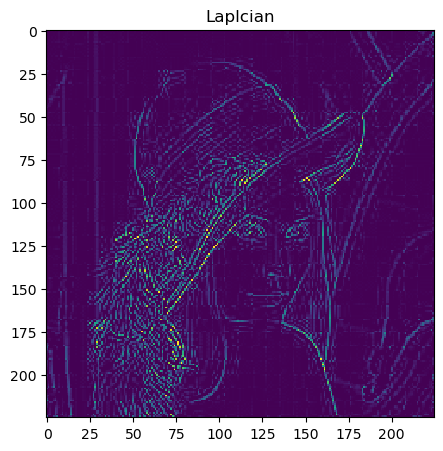

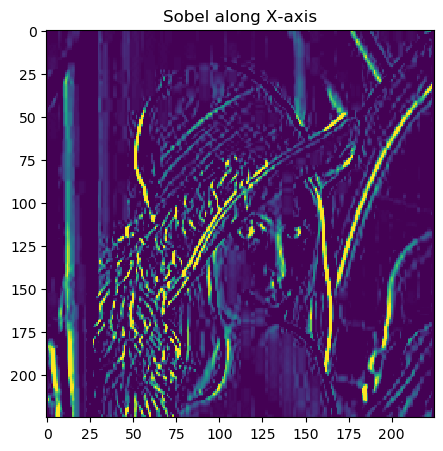

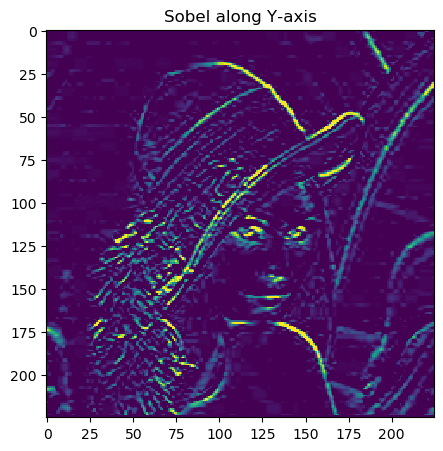

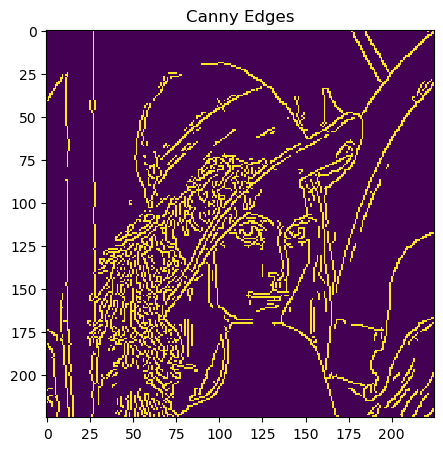

In [8]:
orig_img = gray.copy()

lap = cv2.Laplacian(orig_img,cv2.CV_8UC1)

sobelx = cv2.Sobel(orig_img,cv2.CV_8UC1,1,0,ksize=3)
sobely = cv2.Sobel(orig_img,cv2.CV_8UC1,0,1,ksize=3)

canny = cv2.Canny(orig_img,100,150)

display(orig_img, 'Original Image')
display(lap, 'Laplcian')
display(sobelx, 'Sobel along X-axis')
display(sobely, 'Sobel along Y-axis')
display(canny, 'Canny Edges')

### Morphological Operations

- Erosion 
- Dilation 
- Opening 
- Closing

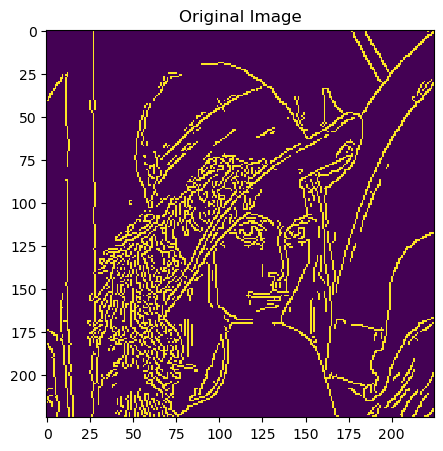

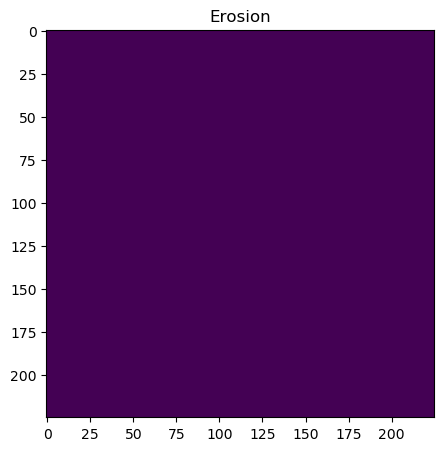

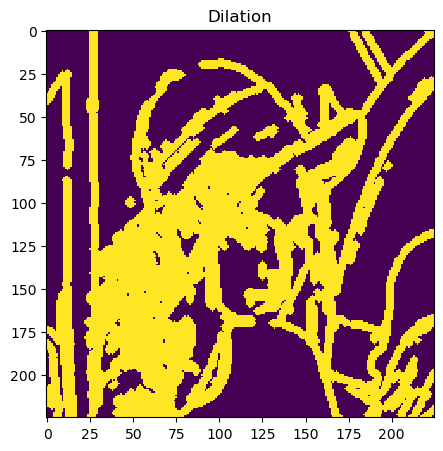

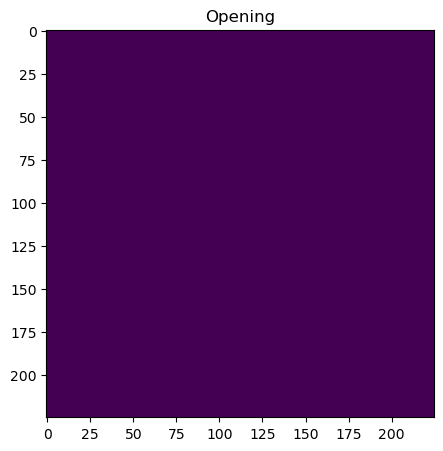

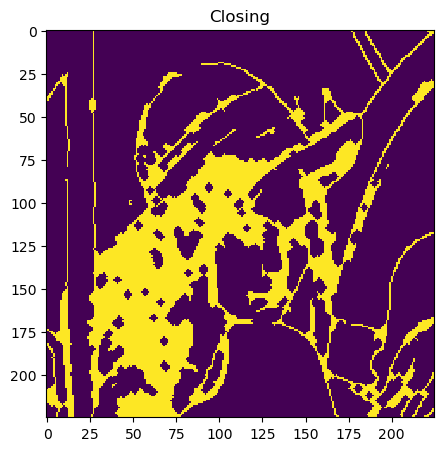

In [9]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3))

orig_img = canny.copy()
erosion = cv2.erode(orig_img,kernel,iterations = 2)
dilation = cv2.dilate(orig_img,kernel,iterations = 2)
opening = cv2.morphologyEx(orig_img,cv2.MORPH_OPEN,kernel,iterations = 2)
closing = cv2.morphologyEx(orig_img,cv2.MORPH_CLOSE,kernel,iterations = 2)

display(orig_img, 'Original Image')
display(erosion, 'Erosion')
display(dilation, 'Dilation')
display(opening, 'Opening')
display(closing, 'Closing')

### Corner Detection (Harris)

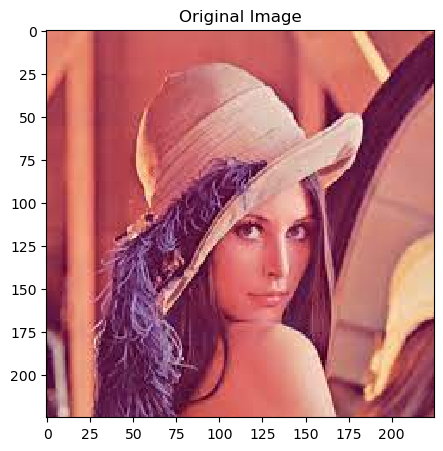

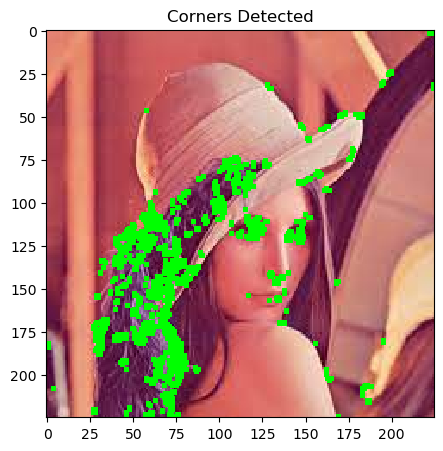

In [10]:
img_corners = rgb.copy()
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_img = np.float32(gray_img)
corners = cv2.cornerHarris(gray_img, blockSize=2, ksize=3, k=0.04)
corners = cv2.dilate(corners, None)
img_corners[corners > 0.01 * corners.max()] = [0, 255, 0]

display(rgb, 'Original Image')
display(img_corners, 'Corners Detected')

# Basics of PyTorch

### Tensors 
Tensors are similar to NumPy’s ndarrays, except that tensors can run on GPUs or other hardware accelerators.

### Import Libraries

In [11]:
import torch
import numpy as np

### Initializing a Tensor


In [12]:

a = torch.tensor(10)
b = torch.tensor(11)

print(a)

tensor(10)


In [13]:
c = a+b
print(c)
print(type(c))
print(c.item())

tensor(21)
<class 'torch.Tensor'>
21


In [14]:
print(c.device)

cpu


In [15]:
if torch.cuda.is_available():
    c = c.to('cuda')
    
c.device

device(type='cuda', index=0)

In [16]:
data = [[1, 2],[3, 4]]
x_data = torch.tensor(data)

np_array = np.array(data)
tensor_array = torch.from_numpy(np_array)

print(type(np_array))
print(type(tensor_array))

<class 'numpy.ndarray'>
<class 'torch.Tensor'>


In [17]:

random = torch.rand((3,3))
ones = torch.ones((3,3))
zeros = torch.zeros((3,3))

print(f"Random Tensor: \n {random} \n")
print(f"Ones Tensor: \n {ones} \n")
print(f"Zeros Tensor: \n {zeros}")

print(f"Shape: {random.shape}")
print(f"Datatype: {random.dtype}")
print(f"Stored on Device: {random.device}")



Random Tensor: 
 tensor([[0.1312, 0.6548, 0.6882],
        [0.6771, 0.7047, 0.2496],
        [0.0443, 0.5501, 0.7635]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
Shape: torch.Size([3, 3])
Datatype: torch.float32
Stored on Device: cpu


# TorchVision

### Loading required libraries

In [1]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from tqdm import tqdm as tqdm

### Loading Dataset

In [18]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

  0%|          | 0/26421880 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [3]:
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

  0%|          | 0/26421880 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Visualizing Random Images from Dataset

In [ ]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()